<a href="https://colab.research.google.com/github/mbk-dev/publications_RUS/blob/main/18%20pension_strategies_okama.ipynb"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab" title="Open and Execute in Google Colaboratory"></a>

# Создание и тестирование пенсионных инвестиционных стратегий с помощью Okama

Если вы когда-нибудь задумывались о том, на сколько лет хватит ваших накоплений после выхода на пенсию — эта статья для вас. Мы разберём, как с помощью open-source библиотеки [okama](https://github.com/mbk-dev/okama) для Python можно моделировать и тестировать различные стратегии снятия денег с инвестиционного портфеля. От классического «правила 4%» до продвинутых адаптивных стратегий — всё с примерами кода.

**okama** — это библиотека для количественного анализа инвестиционных портфелей, которая поставляется вместе с бесплатной базой исторических данных. Она поддерживает российские активы (Мосбиржа, индексы, валюты ЦБ, инфляция Росстата), зарубежные акции и ETF, товарные активы, а также методы Монте-Карло, оптимизацию по Марковицу и бэктесты с учётом денежных потоков. Именно последнее нам и понадобится для моделирования пенсионных стратегий.

## 1. Что такое инвестиционный портфель пенсионера

На этапе накопления инвестор регулярно пополняет портфель. Его задача — максимизировать капитал к моменту выхода на пенсию. Но в день выхода на пенсию всё переворачивается: вместо пополнения начинаются регулярные изъятия. И тут возникает главный вопрос пенсионного планирования — *сколько можно снимать каждый год, чтобы деньги не закончились слишком рано?*

Этот вопрос нетривиален по нескольким причинам:

- **Риск последовательности доходностей** (Sequence of returns risk) — если рынок сильно упадёт в первые годы после выхода на пенсию, портфель может истощиться гораздо быстрее, даже если средняя доходность за весь период нормальная.
- **Инфляция** — покупательная способность фиксированной суммы снижается с каждым годом.
- **Неопределённость продолжительности жизни** — сколько лет нужно «протянуть» на накоплениях?

Именно для ответа на эти вопросы и существуют стратегии снятия (withdrawal strategies) — алгоритмы, определяющие, сколько денег пенсионер забирает из портфеля каждый год.

## 2. Упрощённые подходы. Правило 4%

Самый известный подход — **правило 4%**, предложенное финансовым консультантом Уильямом Бенгеном в 1994 году. Идея проста: в первый год пенсии вы снимаете 4% от начальной стоимости портфеля, а в каждый последующий год корректируете эту сумму на инфляцию.

Например, при портфеле в 1 000 000 ₽ вы снимаете 40 000 ₽ в первый год. Если инфляция за год составила 8%, то во второй год вы снимаете уже 43 200 ₽ — и так далее, независимо от того, как ведёт себя рынок.

Бенген протестировал эту стратегию на исторических данных за период с 1926 года и обнаружил, что 4% — максимальная начальная ставка, при которой портфель из акций и облигаций США «выживал» как минимум 30 лет даже в наихудших сценариях.

**Плюсы:** предсказуемый стабильный доход, простота реализации.

**Минусы:** стратегия полностью игнорирует текущее состояние рынка. В хорошие годы вы недополучаете, а в плохие — продолжаете снимать фиксированную сумму, ускоряя истощение портфеля. Кроме того, правило 4% было рассчитано для рынка США, и его применимость к другим рынкам (включая российский с его более высокой волатильностью и инфляцией) — вопрос открытый.

Другой простой подход — **снятие фиксированного процента** от текущей стоимости портфеля (например, те же 4% каждый год, но уже от текущего баланса). В этом случае портфель формально никогда не обнулится, но доход становится крайне волатильным: при падении рынка на 30% ваш годовой «доход» тоже упадёт на 30%.

## 3. Знакомство с okama: установка и первый портфель

Библиотека [okama](https://github.com/mbk-dev/okama) — это open-source инструмент на Python для анализа и оптимизации инвестиционных портфелей. Она работает с бесплатной базой исторических данных через API и поддерживает бэктестинг стратегий с денежными потоками через класс `PortfolioDCF`, доступный как атрибут `Portfolio.dcf`.

### Установка

Установка выполняется одной командой в терминале:

```bash
pip install okama
```

Все необходимые зависимости — `pandas`, `numpy`, `matplotlib`, `scipy` и пара других — подтянутся автоматически, отдельно ставить ничего не нужно. Если вы запускаете код в Jupyter Notebook или Google Colab, можно использовать магическую команду `%pip install -U okama` прямо в ячейке.

После установки импортируем библиотеки, которые будем использовать во всех примерах:

In [1]:
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = [12.0, 6.0]

import pandas as pd
import okama as ok

In [2]:
ok.__version__

'2.0.1'

### Создаём портфель

Для примеров будем использовать портфель из российских индексов и золота:

- **MCFTR.INDX** — Индекс Мосбиржи полной доходности (акции)
- **RUCBTRNS.INDX** — Индекс корпоративных облигаций Мосбиржи
- **GC.COMM** — физическое золото

Класс `Portfolio` задаёт базовую инвестиционную стратегию (активы, веса и ребалансировку) ещё до добавления денежных потоков:

In [3]:
pf = ok.Portfolio(
    ["MCFTR.INDX", "RUCBTRNS.INDX", "GC.COMM"],
    weights=[0.60, 0.35, 0.05],
    ccy="RUB",
    inflation=True,
    last_date="2026-02",
    rebalancing_strategy=ok.Rebalance(period="year"),
    symbol="Pension_portfolio.PF",
)
pf

symbol                                       Pension_portfolio.PF
assets                       [MCFTR.INDX, RUCBTRNS.INDX, GC.COMM]
weights                                         [0.6, 0.35, 0.05]
rebalancing_period                                           year
rebalancing_abs_deviation                                    None
rebalancing_rel_deviation                                    None
currency                                                      RUB
inflation                                                RUB.INFL
first_date                                                2003-01
last_date                                                 2026-02
period_length                                  23 years, 2 months
dtype: object

### IndexationStrategy — стратегия с индексацией (аналог правила 4%)

Класс `IndexationStrategy` реализует стратегию с фиксированной суммой снятия, которая индексируется на инфляцию. Это прямой аналог правила 4%. Отрицательное значение `amount` означает снятие, положительное — пополнение.

In [4]:
ind = ok.IndexationStrategy(pf)  # создаём стратегию, привязанную к портфелю

ind.initial_investment = 10_000   # размер начальных вложений
ind.amount = -2_500               # размер годового снятия
ind.frequency = "year"            # частота — раз в год
ind.indexation = "inflation"      # индексация на среднюю инфляцию
ind

Strategy name                           fixed_amount
Portfolio symbol                Pension_portfolio.PF
Cash flow initial investment                   10000
Cash flow frequency                             year
Cash flow strategy                      fixed_amount
Cash flow amount                               -2500
Cash flow indexation                        0.083798
dtype: object

Привязываем стратегию к портфелю и запускаем бэктест:

In [5]:
pf.dcf.cashflow_parameters = ind

Дальше мы можем "прогнать" стратегию через исторические данные (бэктестинг).

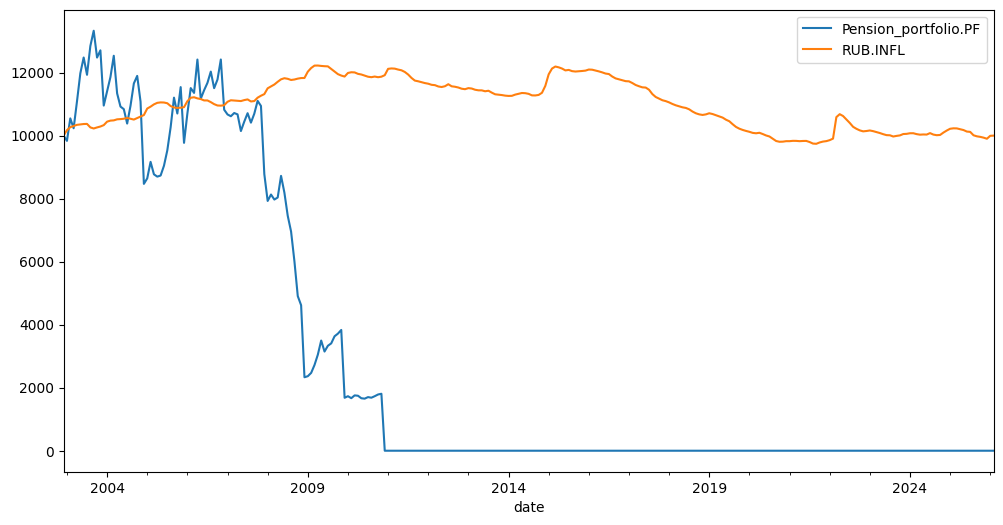

In [6]:
pf.dcf.wealth_index(discounting="pv", include_negative_values=False).plot();

При снятии 2 500 из 10 000 (25% в год!) портфель истощается очень быстро. Узнаем, сколько "протянул" портфель до обнуления баланса. Это называется "периодом выживания" (внимание, портфеля а не пенсионера):

In [7]:
pf.dcf.survival_period_hist()  # количество лет

8.0

Точная дата обнуления портфеля при тестировнии на исторических данных:

In [8]:
pf.dcf.survival_date_hist()

Timestamp('2010-12-31 00:00:00')

Уменьшим снятие до разумного уровня:

In [9]:
pf.dcf.cashflow_parameters.amount = -600  # ~6% в год

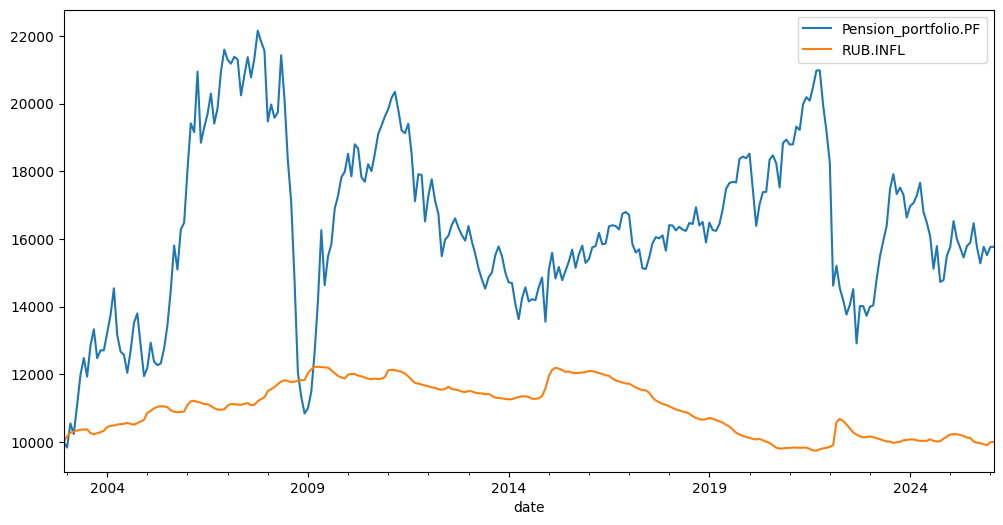

In [10]:
pf.dcf.wealth_index(discounting="pv", include_negative_values=False).plot();

С меньшим снятием портфель проходит исторический бэктест. Более того,реальный (с учётом инфляции) баланс увеличивается.

Но пройдёт ли стратегия проверку будущим? Для ответа нужна **симуляция Монте-Карло**.

#### Симуляция Монте-Карло

Параметры теста Монте-Карло задаются в `set_mc_parameters`:

In [11]:
pf.dcf.set_mc_parameters(
    distribution="t",   # t-распределение Стьюдента (тяжёлые хвосты)
    period=60,          # прогноз на 60 лет
    mc_number=400,      # 400 случайных сценариев
)

Теперь можно посмотреть наглядно как вел себя портфель с изъятиями в каждом из случайных сценариев с помощью `plot_forecast_monte_carlo()`.

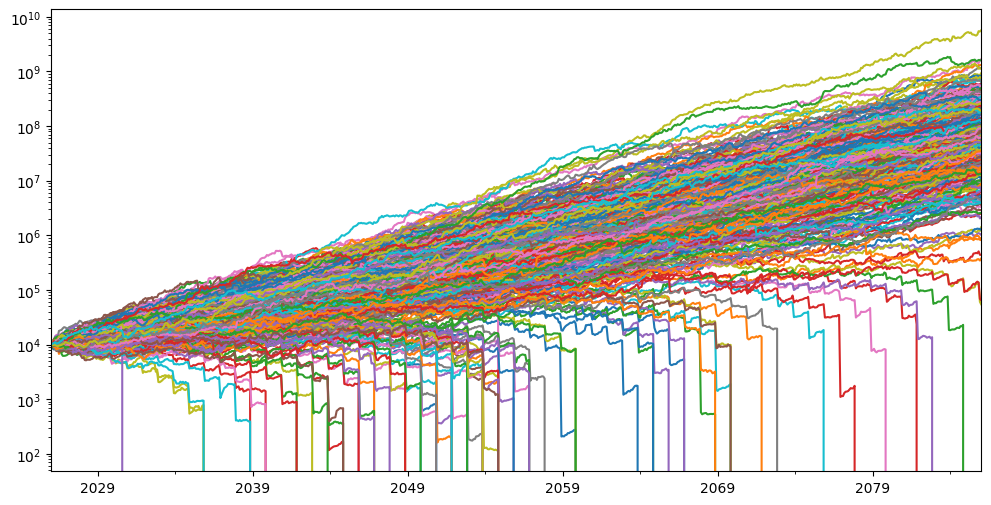

In [12]:
pf.dcf.plot_forecast_monte_carlo(backtest=False)
plt.yscale("log")  # логарифмическая шкала для наглядности

Распределение "периодов выживания" по сценариям:

In [13]:
s = pf.dcf.monte_carlo_survival_period()
s

0      60.0
1      60.0
2      60.0
3      60.0
4      60.0
       ... 
395    60.0
396    60.0
397    60.0
398    60.0
399    60.0
Length: 400, dtype: float64

In [14]:
s.quantile(5 / 100)    # худшие 5% сценариев

np.float64(20.9)

In [15]:
s.quantile(50 / 100)   # медианный сценарий

np.float64(60.0)

То есть в худших сценариях портфеля хватало на 22 года. А в медианном (наиболее вероятном) - на 60 лет. 

#### Поиск максимальной безопасной ставки снятия

Метод `find_the_largest_withdrawals_size()` автоматически находит максимальное снятие, при котором портфель «выживает» с заданной вероятностью. Поддерживаются три цели:

- `survival_period` — сохранить положительный баланс заданное число лет (этот срок должен быть меньше срока прогноза в Монте-Карло)
- `maintain_balance_pv` — сохранить покупательную способность портфеля (реальный баланс)
- `maintain_balance_fv` — сохранить номинальный баланс

*ВНИМАНИЕ: метод может работать медленно при большом числе сценариев Монте-Карло и длинных сроках прогноза.*

In [16]:
result = pf.dcf.find_the_largest_withdrawals_size(
    goal="survival_period",
    target_survival_period=30,   # портфель должен прожить 30 лет
    percentile=5,                # даже в 5% худших сценариев
)

2026-04-16 07:23:01,115 - INFO - Iteration 0: error_rel=0.938, gradient=0.000
2026-04-16 07:23:08,554 - INFO - Iteration 1: error_rel=0.937, gradient=-0.002
2026-04-16 07:23:16,443 - INFO - Iteration 2: error_rel=0.870, gradient=-0.067
2026-04-16 07:23:23,407 - INFO - Iteration 3: error_rel=0.737, gradient=-0.133
2026-04-16 07:23:30,704 - INFO - Iteration 4: error_rel=0.337, gradient=-0.400
2026-04-16 07:23:38,287 - INFO - Iteration 5: error_rel=1.000, gradient=0.663
2026-04-16 07:23:45,636 - INFO - Iteration 6: error_rel=0.443, gradient=-0.557
2026-04-16 07:23:52,922 - INFO - Iteration 7: error_rel=0.172, gradient=-0.271
2026-04-16 07:23:59,718 - INFO - Iteration 8: error_rel=0.203, gradient=0.032
2026-04-16 07:24:06,800 - INFO - Iteration 9: error_rel=0.137, gradient=-0.067
2026-04-16 07:24:14,164 - INFO - Iteration 10: error_rel=0.063, gradient=-0.073
2026-04-16 07:24:14,165 - INFO - Solution found: -478.52 or 4.79% after 11 steps.


In [17]:
result.withdrawal_abs  # абсолютная сумма снятия

-478.515625

In [18]:
result.withdrawal_rel  # относительная (доля от начальных вложений)

0.0478515625

Если требуется более точный результат, можно настроить параметр `tolerance_rel` (по умолчанию допускается 10% отклонение от цели).

Проверим результат — подставим найденную сумму в стратегию изъятий и пересчитаем прогноз:

In [19]:
ind.amount = result.withdrawal_abs
ind

Strategy name                           fixed_amount
Portfolio symbol                Pension_portfolio.PF
Cash flow initial investment                   10000
Cash flow frequency                             year
Cash flow strategy                      fixed_amount
Cash flow amount                         -478.515625
Cash flow indexation                        0.083798
dtype: object

In [20]:
s = pf.dcf.monte_carlo_survival_period()
s.quantile(5 / 100)  # 5% самых плохих сценариев

np.float64(35.9)

### PercentageStrategy — стратегия фиксированного процента

Класс `PercentageStrategy` реализует снятие фиксированного процента от текущей стоимости портфеля. Это похоже на популярное «правило 4%», но здесь можно тестировать любую ставку.

In [21]:
pc = ok.PercentageStrategy(pf)
pc.initial_investment = 10_000
pc.frequency = "year"
pc.percentage = -0.12   # 12% от текущего баланса каждый год
pc

Strategy name                       fixed_percentage
Portfolio symbol                Pension_portfolio.PF
Cash flow initial investment                   10000
Cash flow frequency                             year
Cash flow strategy                  fixed_percentage
Cash flow percentage                           -0.12
dtype: object

In [22]:
pf.dcf.cashflow_parameters = pc

12% — заведомо агрессивная ставка, значительно превышающая рекомендуемые 4%. Проверим, переживёт ли портфель историю:

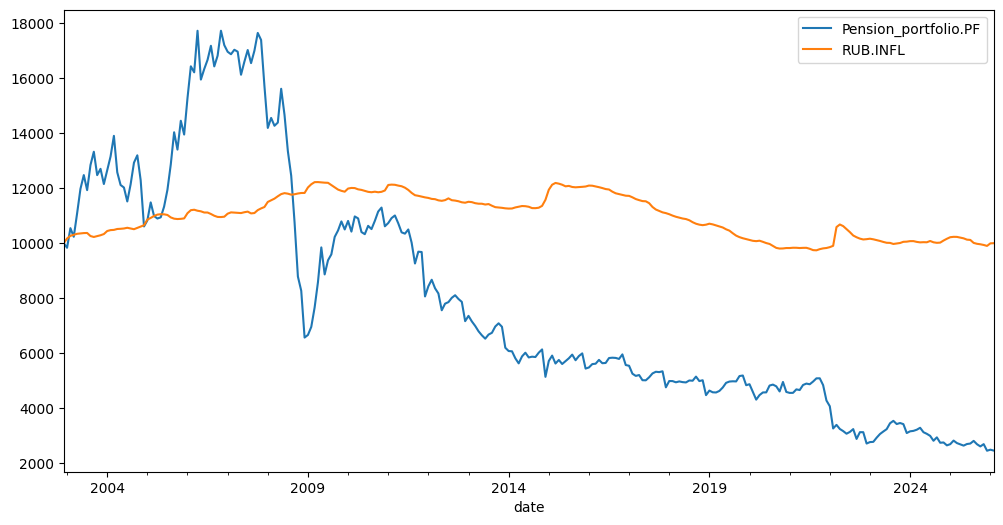

In [23]:
pf.dcf.wealth_index(discounting="pv", include_negative_values=False).plot();

Портфель заметно «худеет», но формально не обнуляется — ведь мы всегда снимаем лишь долю от остатка. Главный минус виден на графике денежных потоков. Они очень сильно меняются от года к году:

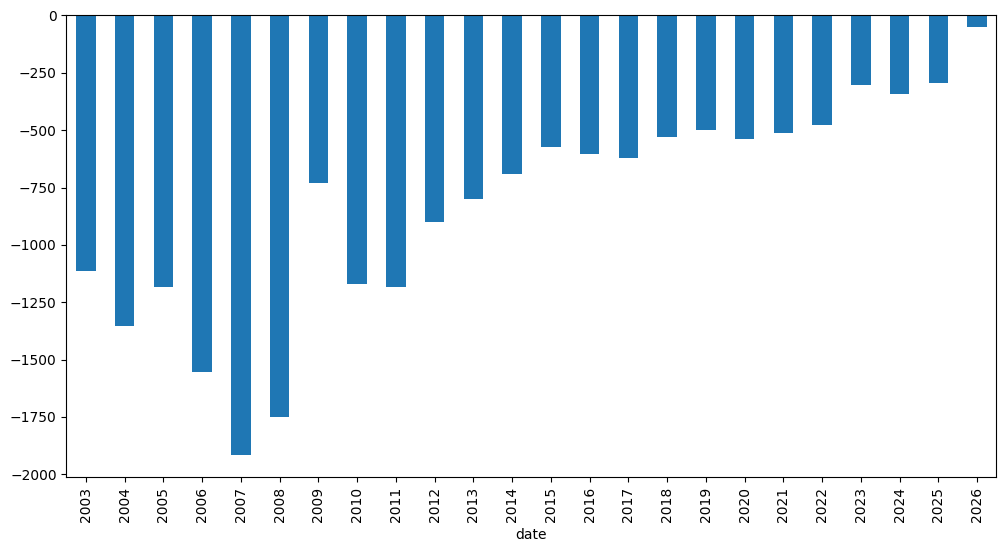

In [24]:
cf_percentage = pf.dcf.cash_flow_ts(discounting="pv").resample("Y").sum()
cf_percentage.plot(kind="bar");

#### Монте-Карло для PercentageStrategy

<Axes: >

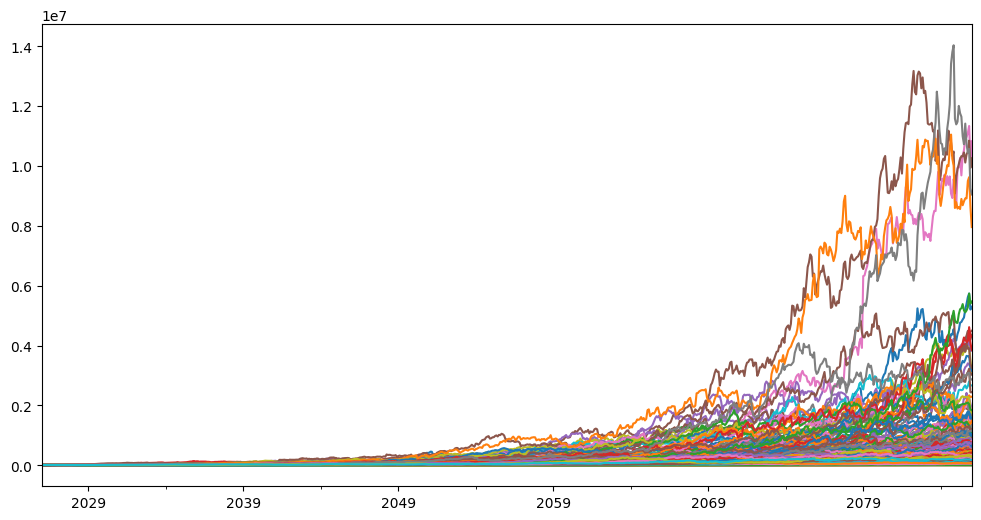

In [ ]:
pf.dcf.plot_forecast_monte_carlo(backtest=False);

В стратегии с фиксированным процентом баланс формально не обнуляется даже на 5й перцентили (в очень плохих сценариях). Параметр `threshold` определяет, когда баланс считается нулевым (доля от начальных инвестиций):

In [26]:
s_percentage = pf.dcf.monte_carlo_survival_period(threshold=0.01)  # если баланс равен 1%, то портфель считается "обнулившимся"
s_percentage.describe([0.05, 0.20, 0.50, 0.70])

count    400.000000
mean      59.767750
std        2.058027
min       32.900000
5%        60.000000
20%       60.000000
50%       60.000000
70%       60.000000
max       60.000000
dtype: float64

Хотя портфель «жив», реальные выплаты к концу периода становятся ничтожными. Чтобы посмотреть на размер выплат в прогнозе возьмем один из сценариев (сценарий номер 0):

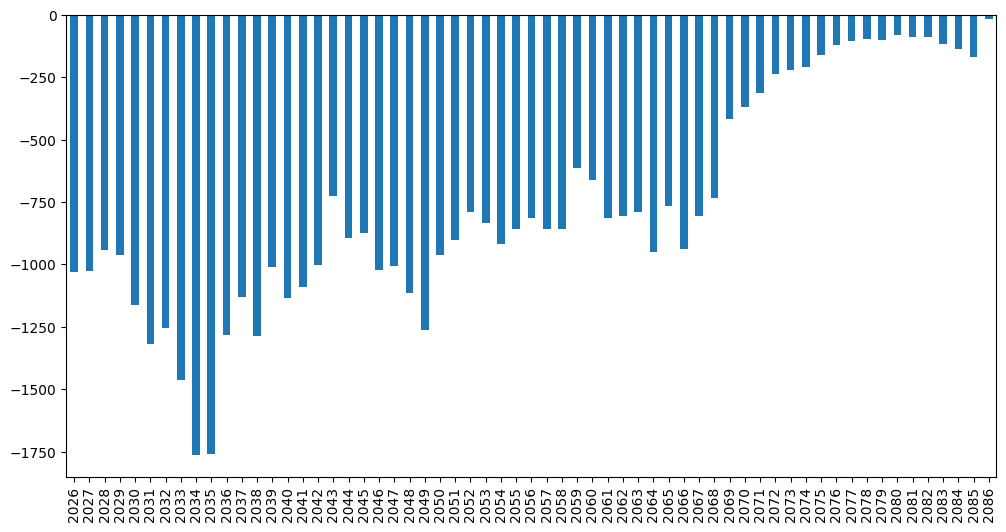

In [27]:
mc_cashflow_percentage = pf.dcf.monte_carlo_cash_flow(discounting="pv")
mc_cashflow_percentage[0].resample("Y").sum().plot(kind="bar");

Статистика по выплатам в последний год (то есть чрез 60 лет) во всех сценариях тоже неутешительна.

In [28]:
mc_cashflow_percentage.iloc[-1, :].describe()

count    400.000000
mean     -43.871970
std       82.508509
min     -755.491250
25%      -45.844525
50%      -17.808622
75%       -7.386302
max        0.000000
Name: 2086-01, dtype: float64

#### Наследство: сохранение баланса портфеля

Если цель — оставить наследство (сохранить покупательную способность портфеля), можно найти максимальную безопасную процентную ставку снятия. Пусть пенсионер хочет оставить наследство через 30 лет.

In [29]:
pf.dcf.set_mc_parameters(distribution="t", period=30, mc_number=400)

In [30]:
pf.dcf.discount_rate = None  # дисконтирование денежных потоков происходит по средней инфляции
pf.dcf

Portfolio symbol            Pension_portfolio.PF
Monte Carlo distribution                       t
Monte Carlo period                            30
Cash flow strategy              fixed_percentage
discount_rate                           0.083798
dtype: object

In [31]:
result = pf.dcf.find_the_largest_withdrawals_size(
    goal="maintain_balance_pv",   # ставим задач - сохранить покупательную способность стартовой суммы денег
    percentile=25,  # денег должно хватить в умеренно пессимистичном сценарии (25й перцентиль)
    threshold=0.10,  # допустимая погрешность 10%
)

2026-04-16 07:24:59,397 - INFO - Iteration 0: error_rel=1.000, gradient=0.000
2026-04-16 07:25:03,460 - INFO - Iteration 1: error_rel=1.000, gradient=-0.000
2026-04-16 07:25:07,815 - INFO - Iteration 2: error_rel=0.997, gradient=-0.003
2026-04-16 07:25:11,919 - INFO - Iteration 3: error_rel=0.786, gradient=-0.211
2026-04-16 07:25:15,976 - INFO - Iteration 4: error_rel=0.131, gradient=-0.655
2026-04-16 07:25:19,642 - INFO - Iteration 5: error_rel=0.533, gradient=0.403
2026-04-16 07:25:23,312 - INFO - Iteration 6: error_rel=0.233, gradient=-0.300
2026-04-16 07:25:27,141 - INFO - Iteration 7: error_rel=0.059, gradient=-0.174
2026-04-16 07:25:27,141 - INFO - Solution found: -703.12 or 7.03% after 8 steps.


Ответ показывает, что при заданной инвестиционной стратегии можно снимать вплоть до 6,8% (с последующей индексацией). Это довольно много. Но не стоит забывать, что здесь рассматривается агрессивный портфель с большим содержанием акций. Риски в такой стратегии больше, а размер изъятий будет очень волатильным, что подойдет далеко не любому пенсионеру.

In [32]:
result.withdrawal_rel

0.0703125

Если достаточно сохранить номинальный (а не реальный) баланс, допустимая ставка снятия может быть еще выше:

In [33]:
result = pf.dcf.find_the_largest_withdrawals_size(
    goal="maintain_balance_fv",
    percentile=25,
    threshold=0.10,
)

2026-04-16 07:25:30,938 - INFO - Iteration 0: error_rel=1.000, gradient=0.000
2026-04-16 07:25:34,761 - INFO - Iteration 1: error_rel=1.000, gradient=-0.000
2026-04-16 07:25:38,609 - INFO - Iteration 2: error_rel=0.959, gradient=-0.041
2026-04-16 07:25:42,338 - INFO - Iteration 3: error_rel=0.994, gradient=0.035
2026-04-16 07:25:45,781 - INFO - Iteration 4: error_rel=0.688, gradient=-0.305
2026-04-16 07:25:49,510 - INFO - Iteration 5: error_rel=0.113, gradient=-0.575
2026-04-16 07:25:53,193 - INFO - Iteration 6: error_rel=0.217, gradient=0.104
2026-04-16 07:25:57,215 - INFO - Iteration 7: error_rel=0.676, gradient=0.459
2026-04-16 07:26:00,818 - INFO - Iteration 8: error_rel=0.523, gradient=-0.152
2026-04-16 07:26:04,702 - INFO - Iteration 9: error_rel=0.456, gradient=-0.068
2026-04-16 07:26:08,607 - INFO - Iteration 10: error_rel=0.304, gradient=-0.152
2026-04-16 07:26:12,409 - INFO - Iteration 11: error_rel=0.424, gradient=0.120
2026-04-16 07:26:15,993 - INFO - Iteration 12: error_re

In [34]:
result.withdrawal_rel

0.15625

## 4. Продвинутые стратегии моделирования снятия денег

Фиксированные стратегии (будь то фиксированная сумма или фиксированный процент) страдают от одной и той же проблемы: они не адаптируются к рыночным условиям. В реальной жизни пенсионер, увидев, что портфель сильно просел, скорее всего, сократит расходы. И наоборот — после хорошего года позволит себе чуть больше.

Именно эту идею формализуют адаптивные стратегии. В okama реализованы два таких подхода: **Vanguard Dynamic Spending (VDS)** и **Cut Withdrawals If Drawdown (CWD)**.

### 4.1. Vanguard Dynamic Spending (VDS)

#### Оригинальное исследование Vanguard

В 2012 году команда исследователей Vanguard (Colleen Jaconetti, Francis Kinniry, Michael DiJoseph, Zoe Odenwalder) представила работу «From Assets to Income: A Goals-Based Approach to Retirement Spending», а в 2017-м — итоговый документ **«A Rule for All Seasons: Vanguard's Dynamic Approach to Retirement Spending»**. Идея — объединить два простых подхода (фиксированная сумма с индексацией и фиксированный процент) в гибридную стратегию.

Алгоритм VDS:

1. Рассчитываем «целевое» снятие как фиксированный процент от **текущей** стоимости портфеля.
2. Сравниваем его с предыдущим снятием, скорректированным на инфляцию.
3. Ограничиваем рост снятия «потолком» (ceiling) — например, не более +5% от прошлогоднего.
4. Ограничиваем падение «полом» (floor) — например, не более −2.5% от прошлогоднего.

Так размер выплат плавно следует за рынком, но без резких скачков в обе стороны. По данным Vanguard, при потолке 5% и поле −2.5% вероятность исчерпания портфеля за 35 лет снижается до нескольких процентов (по сравнению с ~15% при классическом правиле 4%), а средний разброс годовых выплат остаётся комфортным.

#### VDS в okama: класс `VanguardDynamicSpending`

In [35]:
vds = ok.VanguardDynamicSpending(
    parent=pf,
    initial_investment=10_000,
    percentage=-0.12,                 # 12% от текущего баланса
    floor_ceiling=(-0.05, 0.10),      # пол: −5%, потолок: +10%
    adjust_floor_ceiling=True,        # корректировать пол/потолок на инфляцию
    indexation="inflation",
)
pf.dcf.cashflow_parameters = vds

Параметры `floor_ceiling=(-0.05, 0.10)` означают: если рассчитанное снятие на текущий год оказалось ниже прошлогоднего более чем на 5%, оно ограничивается этим полом. Если выше более чем на 10% — ограничивается потолком. Флаг `adjust_floor_ceiling=True` включает корректировку порогов на инфляцию.  
**Важно:** VDS работает только со снятиями (отрицательные значения `amount`). Разрешена частота снятий только "раз в год".

#### Бэктест VDS

На исторических данных график баланса портфеля при стратегии VDS выглядит очень похоже на обычное снятие процента.

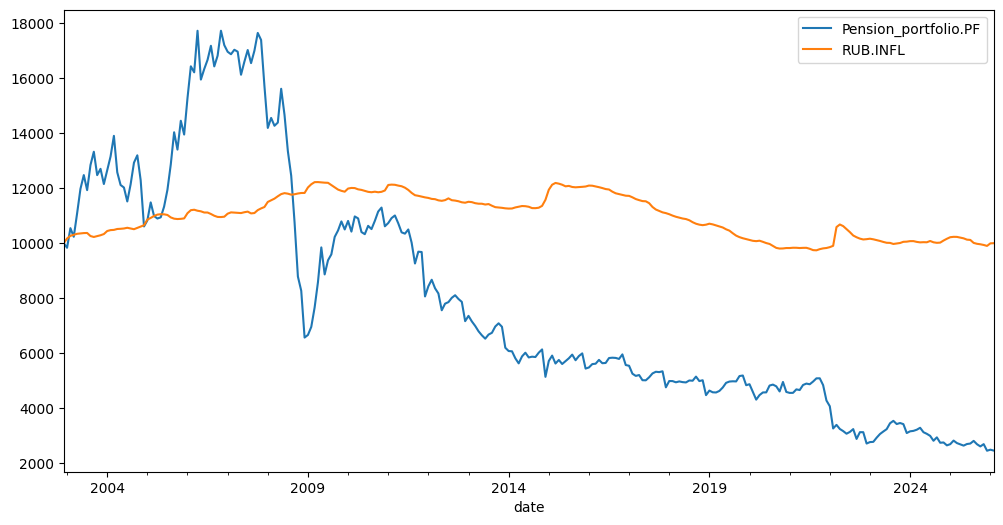

In [36]:
pf.dcf.wealth_index(discounting="pv", include_negative_values=False).plot();

Размер снятий по годам. В отличие от чистой `PercentageStrategy`, выплаты меняются значительно плавнее:

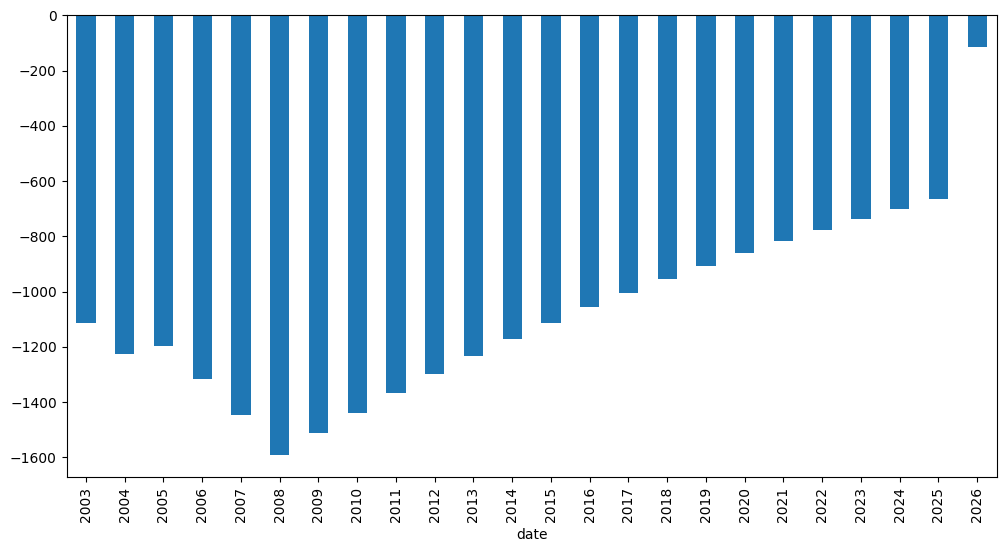

In [37]:
cf_vds = pf.dcf.cash_flow_ts(discounting="pv").resample("Y").sum()
cf_vds.plot(kind="bar");

#### Монте-Карло для VDS

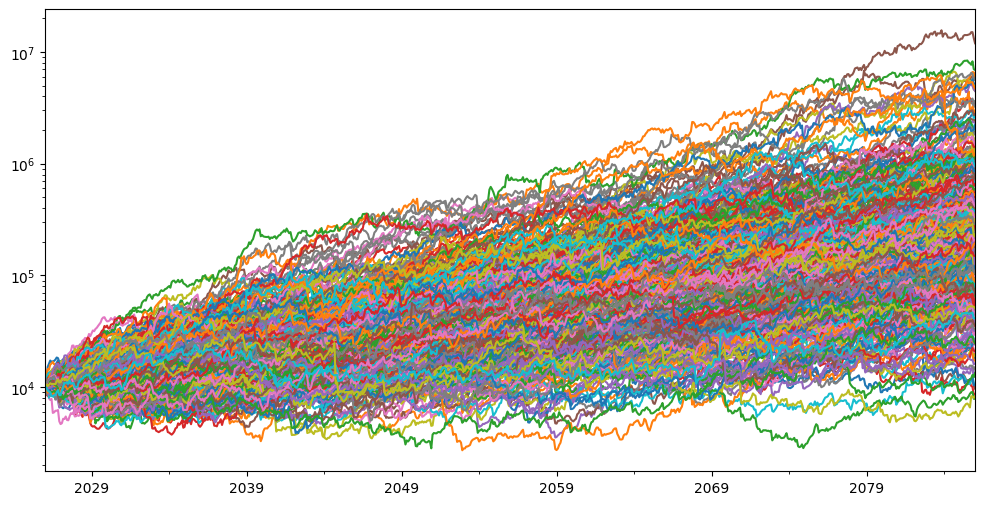

In [38]:
pf.dcf.set_mc_parameters(
    distribution="t",
    period=60,
    mc_number=400,
)
pf.dcf.plot_forecast_monte_carlo(backtest=False)
plt.yscale("log")

In [39]:
s_vds = pf.dcf.monte_carlo_survival_period(threshold=0.05)
s_vds.describe([0.05, 0.20, 0.50, 0.70])

count    400.000000
mean      56.531500
std        7.737968
min       23.300000
5%        36.995000
20%       57.000000
50%       60.000000
70%       60.000000
max       60.000000
dtype: float64

#### Сравнение VDS и PercentageStrategy

Ключевое отличие хорошо видно при визуализации денежных потоков двух случайных сценариев Монте-Карло:

In [40]:
mc_cashflow_vds = pf.dcf.monte_carlo_cash_flow(discounting="pv")

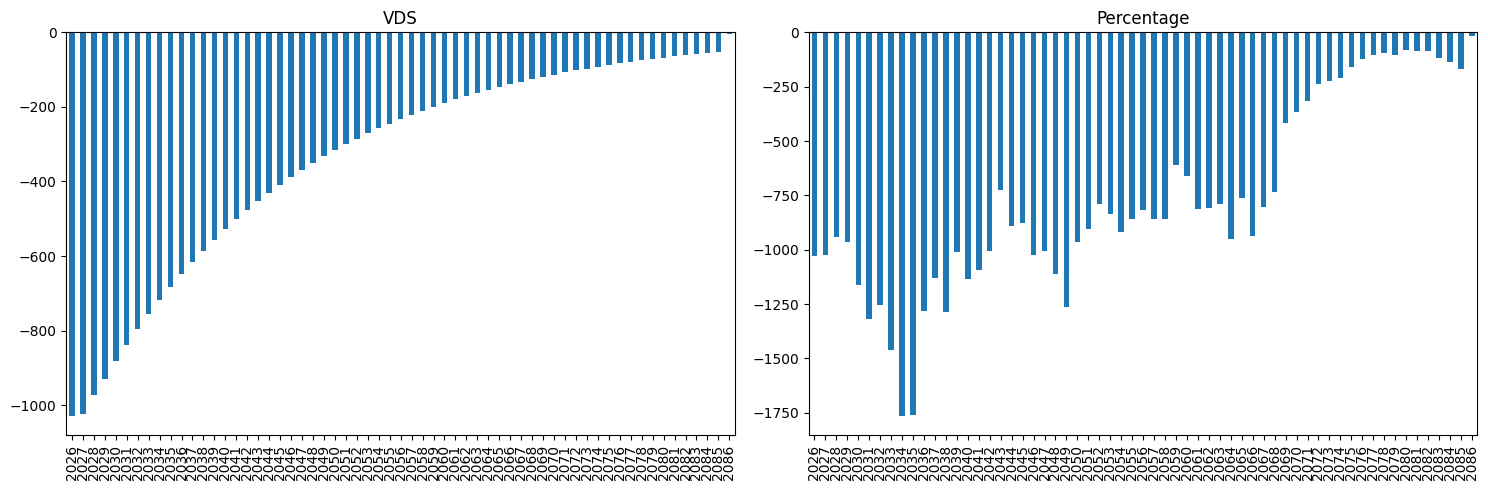

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
mc_cashflow_vds[0].resample("Y").sum().plot(ax=axes[0], kind="bar", title="VDS")
mc_cashflow_percentage[0].resample("Y").sum().plot(ax=axes[1], kind="bar", title="Percentage")
plt.tight_layout()

В `PercentageStrategy` выплаты к концу периода могут упасть в десятки раз. В VDS снижение происходит в несколько раз — "пол" ограничивает скорость падения.

#### Минимальные и максимальные границы снятий

На практике у пенсионера есть минимально необходимый доход (на жизнь) и максимально разумный. VDS позволяет задать эти границы (уже не процентом а номинальной суммой). Установка нижней границы может существенно сократить период выживания портфеля — ведь вы забираете деньги даже в самые плохие годы.

In [42]:
vds.min_max_annual_withdrawals = (
    vds.initial_investment * 0.03,   # минимум: 3% от начальных вложений
    vds.initial_investment * 0.15,   # максимум: 15%
)
vds

Strategy name                                           VDS
Portfolio symbol                       Pension_portfolio.PF
Cash flow initial investment                          10000
Cash flow frequency                                    year
Cash flow strategy                                      VDS
Cash flow percentage                                  -0.12
Minimum annual withdrawal                             300.0
Maximum annual withdrawal                            1500.0
Max and Min withdrawals are indexed                    True
Floor                                                 -0.05
Ceiling                                                 0.1
Floor and Ceiling are indexed                          True
Indexation                                         0.083798
dtype: object

In [43]:
mc_cashflow_vds_limits = pf.dcf.monte_carlo_cash_flow(discounting="pv")

Посмотрим как выглядят 3 профиля снятия денег для VDS, VDS с лимитами и обычный процентный профиль.

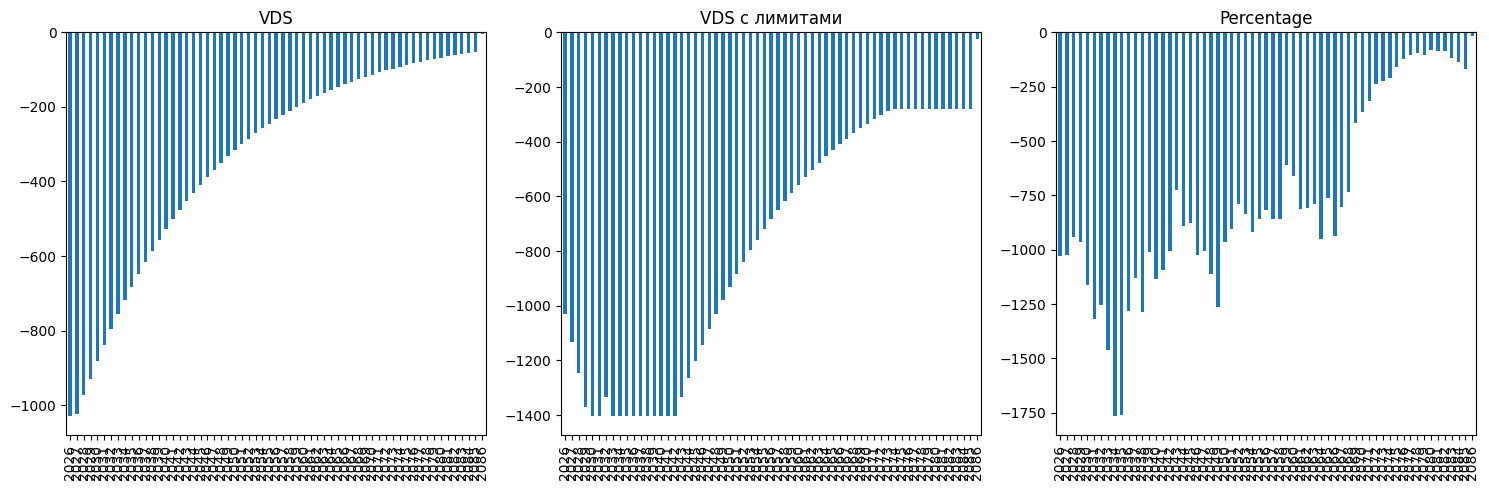

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
mc_cashflow_vds[0].resample("Y").sum().plot(ax=axes[0], kind="bar", title="VDS")
mc_cashflow_vds_limits[0].resample("Y").sum().plot(ax=axes[1], kind="bar", title="VDS с лимитами")
mc_cashflow_percentage[0].resample("Y").sum().plot(ax=axes[2], kind="bar", title="Percentage")
plt.tight_layout()

### 4.2. Cut Withdrawals If Drawdown (CWD)

#### Исследование Guyton–Klinger и концепция «guardrails»

В 2004 году финансовый консультант Джонатан Гайтон опубликовал работу «Decision Rules and Portfolio Management for Retirees: Is the “Safe” Initial Withdrawal Rate Too Safe?». В 2006 году совместно с Уильямом Клингером вышла расширенная версия — **«Decision Rules and Maximum Initial Withdrawal Rates»** в журнале Financial Planning Association.

Ключевая идея — система «ограждений» (guardrails), которая позволяет начать с более высокой ставки снятия (5–6% вместо 4%), но автоматически корректирует её при неблагоприятных рыночных условиях:

- Если текущая ставка снятия (сумма / стоимость портфеля) превышает начальную более чем на 20% — сумма снятия сокращается на 10%.
- Если ставка падает ниже начальной более чем на 20% — сумму можно увеличить на 10%.
- После года с отрицательной доходностью инфляционная корректировка пропускается.

Guyton и Klinger показали, что при этих правилах начальная ставка 5.2–5.6% обеспечивает 99% вероятность «выживания» за 40 лет.

#### CWD в okama: класс `CutWithdrawalsIfDrawdown`

Стратегия CWD в okama реализует родственную идею: когда портфель находится в просадке (drawdown), снятия автоматически сокращаются. Многие инвесторы делают это интуитивно — CWD формализует это поведение.

CWD наследует логику `IndexationStrategy` (фиксированная сумма с индексацией), но добавляет привязку размера снятия к текущей просадке портфеля.

**Важно:** CWD работает только со снятиями (отрицательные значения `amount`).

In [45]:
cwd = ok.CutWithdrawalsIfDrawdown(
    parent=pf,
    initial_investment=10_000,
    frequency="year",
    amount=-1200,              # начальное снятие (12%, для сравнения с VDS)
    indexation="inflation",
)
pf.dcf.cashflow_parameters = cwd
cwd

Strategy name                                      CWD
Portfolio symbol                  Pension_portfolio.PF
Cash flow initial investment                     10000
Cash flow frequency                               year
Cash flow strategy                                 CWD
Cash flow amount                                 -1200
Cash flow indexation                          0.083798
Crash threshold reduction       [(0.2, 0.4), (0.5, 1)]
dtype: object

Ключевой параметр — `crash_threshold_reduction`. Это список пар `(просадка, сокращение_снятия)`. Каждая пара определяет: при какой просадке портфеля на сколько уменьшается снятие:

In [46]:
cwd.crash_threshold_reduction = [
    (0.05, 0.20),   # просадка ≥5%  → снятие сокращается на 20%
    (0.10, 0.40),   # просадка ≥10% → сокращение на 40%
    (0.20, 0.50),   # просадка ≥20% → сокращение на 50%
    (0.30, 1.00),   # просадка ≥30% → снятие полностью прекращается
]
cwd

Strategy name                                                                 CWD
Portfolio symbol                                             Pension_portfolio.PF
Cash flow initial investment                                                10000
Cash flow frequency                                                          year
Cash flow strategy                                                            CWD
Cash flow amount                                                            -1200
Cash flow indexation                                                     0.083798
Crash threshold reduction       [(0.05, 0.2), (0.1, 0.4), (0.2, 0.5), (0.3, 1.0)]
dtype: object

#### Бэктест CWD

Посмотрим на исторических данных, как вел себя портфель, если начальная ставка изъятий была равна 12% (это очень много).

In [47]:
pf.dcf.discount_rate = None  # ставка дисконтирована равна средней инфляции

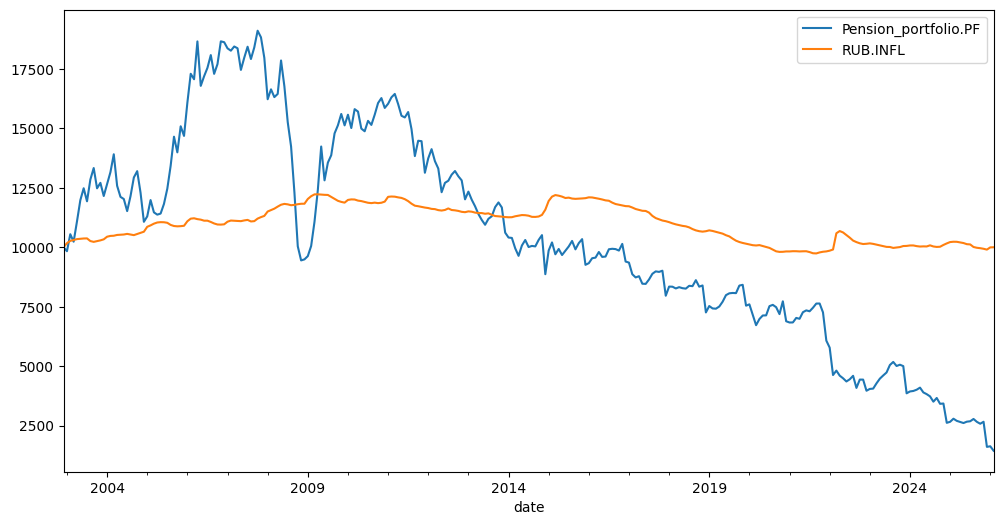

In [48]:
pf.dcf.wealth_index(discounting="pv", include_negative_values=False).plot();

Даже при ставке 12% портфель «выживает» на исторических данных. 

Причина — снятия автоматически сокращались в кризисные периоды. Посмотрим на связь просадок и размера снятий:

<Axes: xlabel='date'>

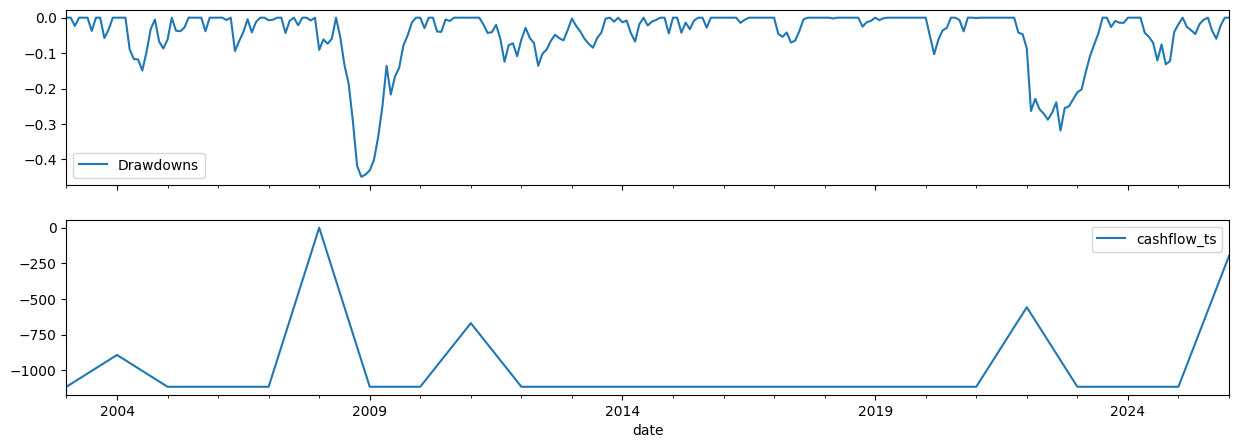

In [49]:
fig, axes = plt.subplots(2, 1, figsize=(15, 5), sharex=True)

pf.drawdowns.plot(ax=axes[0], legend=True, label="Drawdowns")

cf_cwd = pf.dcf.cash_flow_ts(discounting="pv").resample("Y").sum()
cf_cwd = cf_cwd if isinstance(cf_cwd, pd.Series) else cf_cwd.sum(axis=1)
cf_cwd.plot(ax=axes[1], legend="Withdrawals")

12% — заведомо агрессивная ставка, далеко за пределами общепринятых 4%. В отличие от VDS, в CWD снятия растут каждый год (индексация на инфляцию), если только портфель не в просадке. Поэтому подбор разумного размера снятия здесь критически важен.

#### Монте-Карло для CWD

На исторических данных стратегия прошла проверку. Проверим теперь на большем количестве сценариев в Монте-Карло:

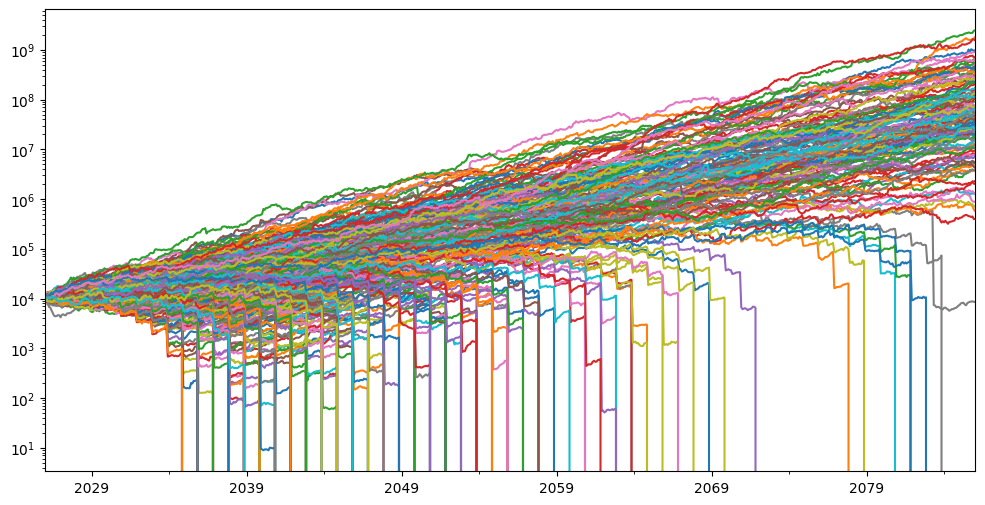

In [50]:
pf.dcf.set_mc_parameters(
    distribution="t",
    period=60,
    mc_number=400,
)
pf.dcf.plot_forecast_monte_carlo(backtest=False)
plt.yscale("log")

Визуально хорошо видно, что при ставке изъятий 12% было много случайных сценариев, которые обнулили портфель раньше срока.

In [51]:
s_cwd = pf.dcf.monte_carlo_survival_period(threshold=0.05)
s_cwd.describe([0.05, 0.25, 0.50, 0.70])

count    400.000000
mean      31.629000
std       20.187809
min        6.900000
5%        10.900000
25%       13.900000
50%       21.000000
70%       60.000000
max       60.000000
dtype: float64

Размер снятия необходимо уменьшить, чтобы нужный период выживания был достигнут даже при 5-м процентиле. Определим его с помощью `find_the_largest_withdrawals_size`:

In [52]:
result = pf.dcf.find_the_largest_withdrawals_size(
    goal="survival_period",
    target_survival_period=30,
    percentile=5,
)

2026-04-16 07:27:56,208 - INFO - Iteration 0: error_rel=0.937, gradient=0.000
2026-04-16 07:28:03,756 - INFO - Iteration 1: error_rel=0.903, gradient=-0.033
2026-04-16 07:28:11,606 - INFO - Iteration 2: error_rel=0.837, gradient=-0.067
2026-04-16 07:28:18,834 - INFO - Iteration 3: error_rel=0.670, gradient=-0.167
2026-04-16 07:28:25,807 - INFO - Iteration 4: error_rel=0.025, gradient=-0.645
2026-04-16 07:28:25,808 - INFO - Solution found: -625.00 or 6.25% after 5 steps.


In [53]:
result.withdrawal_abs   # рекомендуемая сумма снятия

-625.0

In [54]:
result.withdrawal_rel   # в долях от начальных инвестиций

0.0625

Для практически гарантированного выживания портфеля (даже в пессимистичном сценарии) размер снятия пришлось сократить почти вдвое. Но благодаря ограничению снятий во время просадок, CWD позволяет добиться более высокой безопасной ставки по сравнению с обычной `IndexationStrategy`.

#### CWD с полным запретом снятий во время просадки

Возможности CWD хорошо демонстрируются, если снятия полностью остановить во время просадки. Это «экстремальный» сценарий, но он применим на практике — например, когда портфельные снятия не являются основным источником дохода и лишь дополняют пенсию или другие поступления.

In [55]:
cwd.crash_threshold_reduction = [(0.01, 1.0)]  # просадка ≥1% → снятие = 0
cwd

Strategy name                                    CWD
Portfolio symbol                Pension_portfolio.PF
Cash flow initial investment                   10000
Cash flow frequency                             year
Cash flow strategy                               CWD
Cash flow amount                               -1200
Cash flow indexation                        0.083798
Crash threshold reduction              [(0.01, 1.0)]
dtype: object

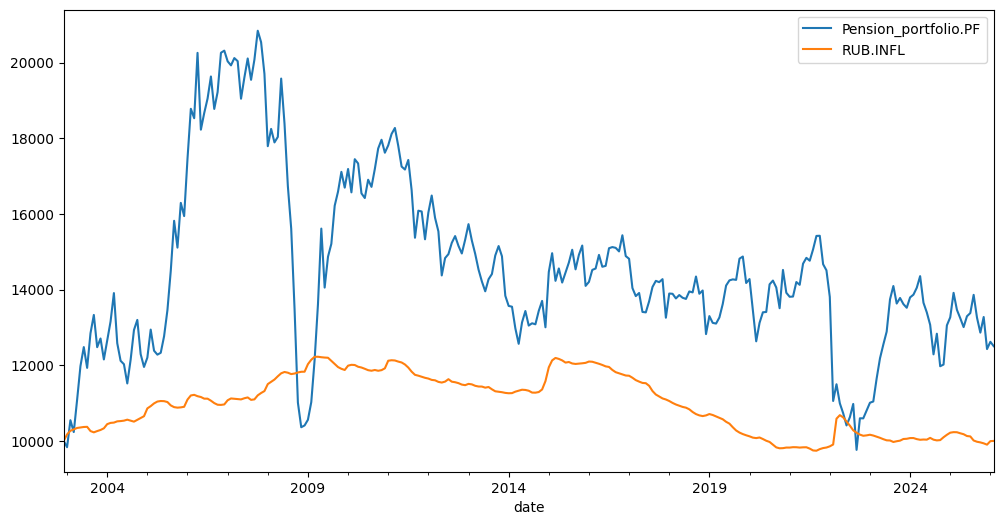

In [56]:
pf.dcf.wealth_index(discounting="pv", include_negative_values=False).plot();

Портфель выживает весь исторический период при ставке 12%. Его реальный размер даже увеличился по сравнению со стартовыми инвестициями. Но инвестору пришлось бы чаще отказываться от выплат:

<Axes: xlabel='date'>

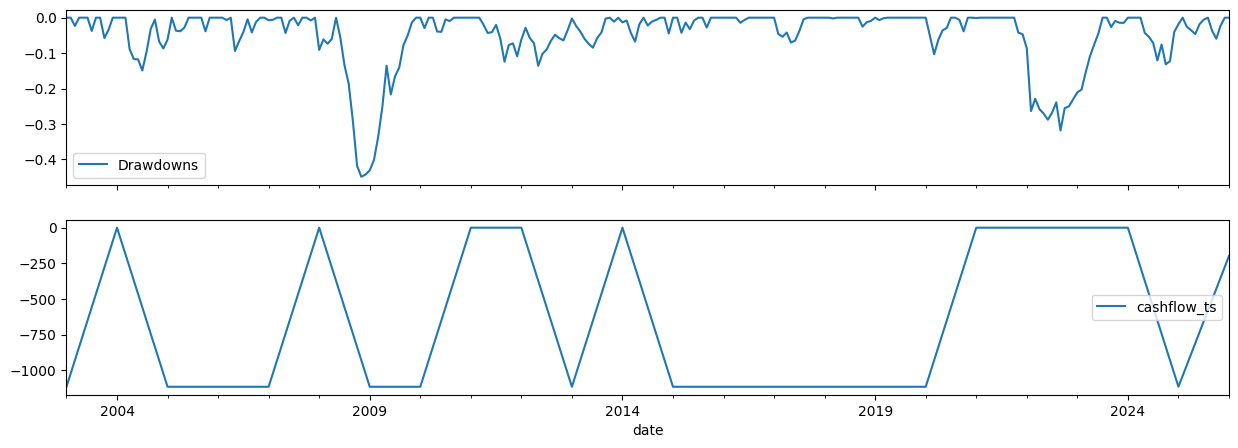

In [57]:
fig, axes = plt.subplots(2, 1, figsize=(15, 5), sharex=True)

pf.drawdowns.plot(ax=axes[0], legend=True, label="Drawdowns")

cf_cwd = pf.dcf.cash_flow_ts(discounting="pv").resample("Y").sum()
cf_cwd.plot(ax=axes[1], legend="Withdrawals")

На графике виден характерный «пилообразный» паттерн. Агрессивный портфель часто уходит в просадку, во время которой снятия прекращаются. Магии здесь нет — средний размер снятия остаётся примерно таким же, как и в сценариях с более мягкими условиями. Это просто другой способ перераспределить снятия во времени.

## 5. Полезные ссылки

- **GitHub:** [github.com/mbk-dev/okama](https://github.com/mbk-dev/okama) — исходный код, issues, discussions
- **Документация:** [okama.readthedocs.io](https://okama.readthedocs.io/) — полная документация по всем классам и методам
- **Примеры (Jupyter Notebooks):** [github.com/mbk-dev/okama/tree/master/examples](https://github.com/mbk-dev/okama/tree/master/examples) — от базовых до продвинутых сценариев, включая [ноутбук по DCF-стратегиям](https://github.com/mbk-dev/okama/blob/master/examples/04%20investment%20portfolios%20with%20DCF.ipynb)
- **Русскоязычный форум:** [community.okama.io](https://community.okama.io/) — обсуждение библиотеки, стратегий и багов на русском языке
- **Интерактивные виджеты:** [okama.io](https://okama.io/) — веб-приложение с финансовыми инструментами на базе okama
- **PyPI:** [pypi.org/project/okama](https://pypi.org/project/okama/) — установка через `pip install okama`

### Публикации на Хабре

- [Open Source в финансах. Проект Okama](https://habr.com/ru/companies/okama/articles/798007/) — обзор библиотеки и основных возможностей
- [Дивидендная доходность Индекса Мосбиржи: как рассчитать за 5 минут с помощью Python](https://habr.com/ru/companies/okama/articles/912096/) — практический пример работы с данными
- [Ребалансировка инвестиционного портфеля с помощью Python и библиотеки okama](https://habr.com/ru/companies/okama/articles/922384/) — стратегии ребалансировки
- [Библиотека Python для доступа к данным ЦБ: cbrapi](https://habr.com/ru/companies/okama/articles/963262/) — смежный проект для работы с данными ЦБ РФ

---

*Okama — это open-source проект, и вклад приветствуется. Если вы нашли ошибку, хотите предложить функцию или просто задать вопрос — используйте [GitHub Discussions](https://github.com/mbk-dev/okama/discussions) или [русскоязычный форум](https://community.okama.io/).*